In [ ]:
# =============================================================================
# GANs (Generative Adversarial Networks) — two networks playing a game (forger vs detective)
# =============================================================================
#
# Last notebook (autoencoders / VAE):
#   one model compresses, then redraws. It is graded on "how close is the copy?"
#
# This notebook:
#   two models compete. One tries to FAKE digits/photos. The other tries to
#   CATCH fakes. They get better by fighting each other.
#
#
# ---------------------------------------------------------------------------
# SCENE — art forger and museum detective
# ---------------------------------------------------------------------------
# Forger (Generator, G):
#   Starts with random scribbles (noise). Tries to paint a digit that looks real.
#
# Detective (Discriminator, D):
#   Sees a picture. Says "real" or "fake".
#
# Rules of the game:
#   - Show D real MNIST photos. D should say "real".
#   - Show D G's paintings. D should say "fake".
#   - G only wins if D says "real" on the fakes.
#
# They train in turns. D gets better at catching. G gets better at fooling.
# After enough rounds, G's fakes look like the training photos.
#
#   random noise z  ──G──▶  fake image
#                              │
#                    ┌─────────┴─────────┐
#                    ▼                   ▼
#              D looks at fake      D looks at real MNIST
#              "fake or real?"      "fake or real?"
#
#
# ---------------------------------------------------------------------------
# Why not just use a VAE?
# ---------------------------------------------------------------------------
# VAE: graded on pixel copy + "keep z in town". Sketches often come out
#      blurry (average of many possible digits).
#
# GAN: graded on "does it FOOL the detective?" Sharp details can survive
#      because nobody asked for an average of all 7s — just "a convincing 7".
#
# Cost: training is drama. D too strong → G gives up. G too strong → D
# guesses. You'll see oscillating losses. That's the game, not a bug by itself.
#
#
# ---------------------------------------------------------------------------
# The three names in the title
# ---------------------------------------------------------------------------
#
# 1) DCGAN  (Deep Convolutional GAN)
#    Same forger/detective game, but both nets use conv layers (image brains),
#    not a flat MLP. Better at photos than a pile of Linear layers.
#    Think: "GAN that actually understands grids of pixels."
#
# 2) Conditional GAN  (cGAN)
#    Plain GAN: "draw ANY digit." You don't get to ask for a 3.
#    cGAN: you pass a LABEL (or extra hint) to both G and D.
#      "G, draw a 3."   "D, is this a REAL 3 or a fake 3?"
#    Same game, now with a request slip attached.
#
# 3) Pix2Pix
#    A famous cGAN for "photo in → photo out":
#      edges → handbag photo
#      day street → night street
#      sketch → filled drawing
#    G sees an input image (not only noise). D sees pairs:
#      (input, real target) vs (input, G's output)
#    Think: "conditional GAN where the condition is another picture."
#
#
# ---------------------------------------------------------------------------
# Tiny vocabulary
# ---------------------------------------------------------------------------
#   z / noise     = random numbers G starts from (like "blank canvas")
#   Generator     = forger
#   Discriminator = detective
#   adversarial   = they train AGAINST each other
#   mode collapse = G finds ONE fake that always fools D and repeats it
#                   (a hundred copies of the same 8)
#
#
# ---------------------------------------------------------------------------
# vs GPT / AE (keep them straight)
# ---------------------------------------------------------------------------
#   GPT   finish the next word
#   AE    compress then rebuild the same item
#   VAE   compress to a neighborhood, can invent by sampling z
#   GAN   invent by fooling a detective (no rebuild-the-input homework)

In [3]:
# =============================================================================
# SETUP — board, dice, and the photo pile before the forger/detective game
# =============================================================================
#
# This cell does not train anyone yet. It only:
#   - imports tools
#   - picks "how big is the blank canvas?" (latent_dim)
#   - loads MNIST photos scaled the way DCGAN likes
#
# Next cells: build Generator + Discriminator, then play the game.
#

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils   # grid of fake images to plot
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)  # same random start → easier to compare reruns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------------------------
# Knobs for the game
# ---------------------------------------------------------------------------
latent_dim = 100   # size of z: how many random numbers the forger starts with
                   # (the "blank canvas". 100 is a DCGAN-paper habit, not magic.)
image_size = 32    # DCGAN stack below wants 32×32 (not raw 28×28)
channels = 1       # gray photos; CIFAR/CelebA would be 3 (RGB)
batch_size = 128   # how many photos D sees in one glance
epochs = 3         # CPU-friendly demo (20 epochs × full MNIST is ~1h+)
max_batches = 80   # only this many batches per epoch (~10k images, not 60k)
lr = 0.0002        # small learning rate — GAN games get drunk if this is big
beta1 = 0.5        # Adam's momentum. DCGAN paper uses 0.5 (default is 0.9).
                   # 0.5 = shorter memory, less "keep rushing the same way".

# ---------------------------------------------------------------------------
# Photos: scale pixels to [-1, 1]
# ---------------------------------------------------------------------------
# MNIST ToTensor() gives [0, 1].
# DCGAN generators usually end with Tanh → output in [-1, 1].
# So we shift the REAL photos into the same range, or D would see
# "reals in 0..1" vs "fakes in -1..1" and cheat with a color-range trick.
#
# Normalize([0.5], [0.5])  does  (pixel - 0.5) / 0.5  →  [-1, 1]
#

transform = transforms.Compose(
    [
        transforms.Resize(32),  # 28→32 so G/D conv math lines up (see Generator cell)
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

train_data = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=0
)  # num_workers=0: Jupyter/macOS often crashes extra DataLoader processes

print(f"Train samples: {len(train_data)}")

# ---------------------------------------------------------------------------
# HOW TO READ THE OUTPUT
# ---------------------------------------------------------------------------
# Using device: cpu   (or cuda)
#   Where tensors live. CPU is fine for this tiny MNIST DCGAN; just slower.
#
# Train samples: 60000
#   60k labeled digits. We will IGNORE labels in plain DCGAN (any digit is
#   "real"). Conditional GAN later will use the 0–9 labels as the request slip.
#
# If download fails: check ./data or run with internet once.


Using device: cpu
Train samples: 60000


In [4]:
# =============================================================================
# GENERATOR — forger: 100 random numbers → a 32×32 "digit"
# =============================================================================
#
# ConvTranspose2d = "upsample with a learned filter" (the opposite of Conv2d).
# We grow a 1×1 blob of z into a full picture:
#
#   z [100] → view as [100, 1, 1]
#         → 4×4  (256 maps)
#         → 8×8
#         → 16×16
#         → 32×32 × 1 channel   Tanh → pixels in [-1, 1]
#
# WHY 32, not 28?
#   These kernel=4, stride=2 layers naturally land on 4,8,16,32.
#   Raw MNIST is 28×28. If D sees 28×28 it shrinks to 3×3, then a 4×4
#   kernel cannot fit → RuntimeError you hit.
#   Fix: Resize(32) on the REAL photos too (and rebuild the DataLoader).
#
# DCGAN habits in this stack:
#   BatchNorm (except last), ReLU, no bias on conv, Tanh at the end.
#

class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=1, feature_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_channels = img_channels
        self.feature_dim = feature_dim

        self.main = nn.Sequential(
            # [B, 100, 1, 1] → [B, 256, 4, 4]
            nn.ConvTranspose2d(latent_dim, feature_dim * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_dim * 4),
            nn.ReLU(True),
            # → [B, 128, 8, 8]
            nn.ConvTranspose2d(feature_dim * 4, feature_dim * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim * 2),
            nn.ReLU(True),
            # → [B, 64, 16, 16]
            nn.ConvTranspose2d(feature_dim * 2, feature_dim, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(True),
            # → [B, 1, 32, 32]
            nn.ConvTranspose2d(feature_dim, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.main(z)


# Rebuild the photo pile at 32×32. Changing `transform` alone does NOT
# update an already-built train_loader from the setup cell.
transform = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)

_x, _ = next(iter(train_loader))
print(f"real batch shape: {tuple(_x.shape)}  (want [B, 1, 32, 32])")
print(f"fake batch shape: {tuple(Generator()(torch.randn(4, latent_dim)).shape)}")


real batch shape: (128, 1, 32, 32)  (want [B, 1, 32, 32])
fake batch shape: (4, 1, 32, 32)


In [5]:
# =============================================================================
# DISCRIMINATOR — detective: 32×32 photo → one number "how real?"
# =============================================================================
#
# Conv2d shrinks the picture (mirror of the generator):
#   32×32 → 16×16 → 8×8 → 4×4 → 1×1  then Sigmoid → probability in (0, 1)
#
# LeakyReLU(0.2): tiny negative leak so D doesn't go fully silent.
# No BatchNorm on the first conv (DCGAN paper habit).
# Last layer: 1 channel, 1×1 — "real vs fake" score, not a 10-class digit ID.
#

class Discriminator(nn.Module):
    def __init__(self, img_channels=1, feature_dim=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(img_channels, feature_dim, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_dim, feature_dim * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_dim * 2, feature_dim * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_dim * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # [B, 1, 32, 32] → [B] probabilities
        return self.main(x).view(-1, 1).squeeze(1)


In [6]:
# =============================================================================
# WEIGHT INIT — start the game from a small, DCGAN-style shuffle
# =============================================================================
# Random default PyTorch init is OK-ish. DCGAN paper uses:
#   Conv weights  ~ Normal(0, 0.02)   (small)
#   BatchNorm w   ~ Normal(1, 0.02), bias = 0
# Small start → less exploding at the first forger/detective clash.
#

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


Starting Training...
(demo: 3 epochs × 80 batches — interrupt kernel if an old 20-epoch run is still going)
Epoch [1/3] Batch 0/469  Loss D: 1.8944, Loss G: 1.7647
Epoch [2/3] Batch 0/469  Loss D: 0.1552, Loss G: 10.0723
Epoch [3/3] Batch 0/469  Loss D: 0.5050, Loss G: 1.8752


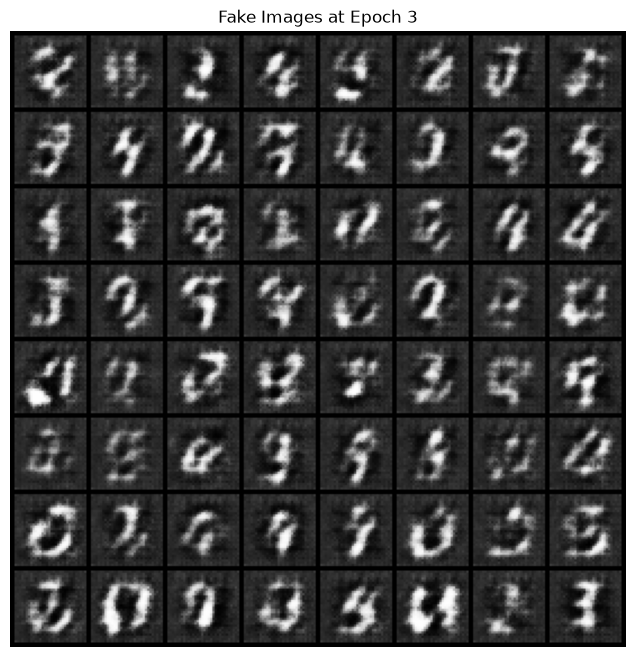

Training finished.


In [7]:
# =============================================================================
# TRAIN — take turns: teach D, then teach G
# =============================================================================
#
# One batch:
#   1) D sees REAL photos, should say 1.0
#   2) D sees FAKE photos (G's), should say 0.0
#      fake_imgs.detach() → do NOT update G while training D
#   3) G tries to make those same fakes look REAL (label 1.0 to D)
#      now gradients DO flow G ← D
#
# BCELoss = "how wrong was the 0/1 guess?"
# Two Adam opts so each player has their own memory.
#
# fixed_noise: SAME 64 z's every epoch so you can watch fakes improve
# instead of a new random set each time.
#
# Stop the old 20-epoch run (interrupt kernel), then re-run THIS cell.
# 3 epochs × 80 batches ≈ minutes on CPU, not an hour.

epochs = 3
max_batches = 80

netG = Generator(latent_dim=latent_dim).to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise = torch.randn(64, latent_dim, device=device)
real_label = 1.0
fake_label = 0.0

G_losses, D_losses = [], []

print("Starting Training...")
print(f"(demo: {epochs} epochs × {max_batches} batches — interrupt kernel if an old 20-epoch run is still going)")
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        if i >= max_batches:
            break
        bsz = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # ----- D: real -----
        netD.zero_grad()
        label = torch.full((bsz,), real_label, dtype=torch.float, device=device)
        errD_real = criterion(netD(real_imgs), label)
        errD_real.backward()

        # ----- D: fake -----
        noise = torch.randn(bsz, latent_dim, device=device)
        fake_imgs = netG(noise)
        label.fill_(fake_label)
        errD_fake = criterion(netD(fake_imgs.detach()), label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        # ----- G: "please call my fakes real" -----
        netG.zero_grad()
        label.fill_(real_label)
        errG = criterion(netD(fake_imgs), label)
        errG.backward()
        optimizerG.step()

        D_losses.append(errD.item())
        G_losses.append(errG.item())

        if i % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] Batch {i}/{len(train_loader)}  "
                f"Loss D: {errD.item():.4f}, Loss G: {errG.item():.4f}"
            )

    # One grid at the end only (plotting every epoch is slow in the notebook)
    if epoch + 1 == epochs:
        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Fake Images at Epoch {epoch+1}")
        plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
        plt.show()

print("Training finished.")

# ---------------------------------------------------------------------------
# HOW TO READ THE OUTPUT
# ---------------------------------------------------------------------------
# real batch shape: (128, 1, 32, 32)   ← must be 32, not 28
#
# Loss D / Loss G: they WRESTLE. Not a smooth MiniGPT drop.
#   D ~ 0.5–1.5, G ~ 1–3 is a common messy-but-alive band.
#   D → 0 and G huge: detective unbeatable, forger stuck.
#   D huge, G → 0: forger already fooling; D collapsed.
#
# Epoch grids: epoch 1 = noise/blobs. Later = digit-ish shapes.
# Same layout each epoch because of fixed_noise.


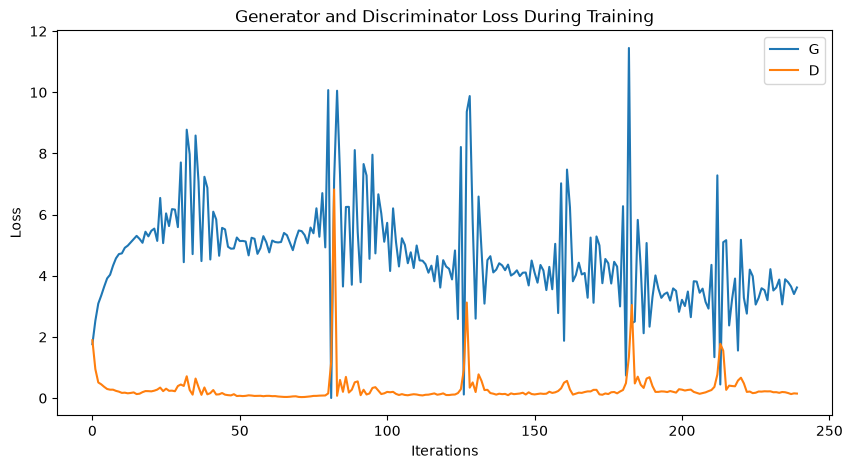

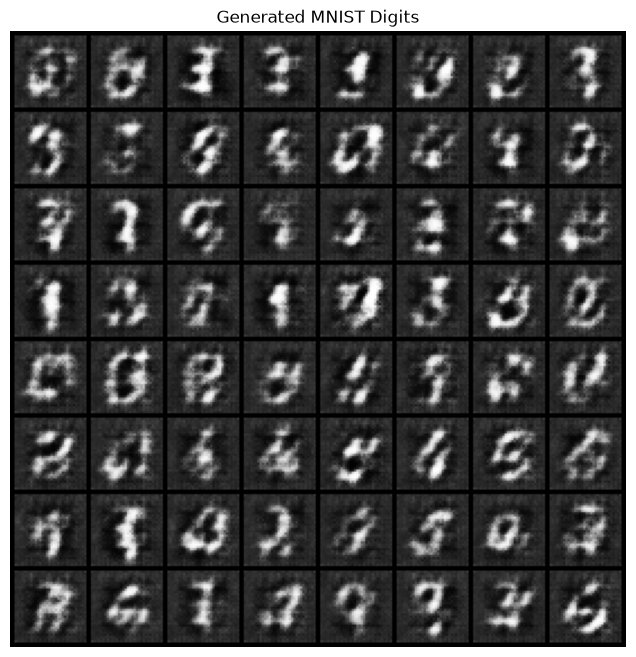

In [8]:
# =============================================================================
# LOOK BACK — loss traces + a fresh sheet of fakes
# =============================================================================
# G and D lines should bounce, not both crash to 0.
# The grid is NEW random z (not fixed_noise) — extra samples after training.
#

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

with torch.no_grad():
    noise = torch.randn(64, latent_dim, device=device)
    fake = netG(noise).detach().cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated MNIST Digits")
plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
plt.show()

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# Loss plot: noisy spaghetti is normal for GANs.
# Grid: recognizable digits = win. One repeated blob everywhere = mode collapse.


In [9]:
# =============================================================================
# CONDITIONAL GAN — same game, plus a request slip ("draw a 3")
# =============================================================================
#
# Plain DCGAN: G only gets random z. You cannot ask for a specific digit.
# cGAN: both G and D also see a LABEL (0–9).
#
#   z + "please draw a 3"  ──G──▶  fake "3"
#   D sees (image, claimed label) and asks: real 3, or fake 3?
#
# Generator trick here:
#   embed the class (10 numbers) and CONCAT to z, then the same
#   upsample stack as DCGAN. Input channels = 100 + 10 = 110.
#

class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, n_classes=10, img_channels=1, feature_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_classes = n_classes
        # class id 0..9 → a small learned vector (length 10 here)
        self.label_embedding = nn.Embedding(n_classes, n_classes)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim + n_classes, feature_dim * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_dim * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_dim * 4, feature_dim * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_dim * 2, feature_dim, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_dim, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        # z: [B, 100]   labels: [B] ints
        label_emb = self.label_embedding(labels)       # [B, 10]
        z = torch.cat([z, label_emb], dim=1)           # [B, 110]
        z = z.view(z.size(0), -1, 1, 1)                # [B, 110, 1, 1]
        return self.main(z)                            # [B, 1, 32, 32]


In [10]:
# =============================================================================
# CONDITIONAL DISCRIMINATOR — detective who also reads the request slip
# =============================================================================
#
# D must not only say "this looks like a digit" but "this looks like THAT digit".
# Otherwise G could ignore the label and still fool D.
#
# Here we paint the label as an extra 32×32 channel and stack it on the photo:
#   image  [B, 1, 32, 32]
#   + map  [B, 1, 32, 32]   (embedding reshaped)
#   →      [B, 2, 32, 32]  into the same conv stack as DCGAN D
#

class ConditionalDiscriminator(nn.Module):
    def __init__(self, img_channels=1, n_classes=10, feature_dim=64):
        super().__init__()
        self.n_classes = n_classes
        self.label_embedding = nn.Embedding(n_classes, 32 * 32)
        self.main = nn.Sequential(
            nn.Conv2d(img_channels + 1, feature_dim, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_dim, feature_dim * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_dim * 2, feature_dim * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_dim * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_dim * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x, labels):
        label_emb = self.label_embedding(labels)
        label_map = label_emb.view(-1, 1, 32, 32)
        x = torch.cat([x, label_map], dim=1)
        return self.main(x).view(-1, 1).squeeze(1)


Starting Conditional GAN Training...
(demo: 3 epochs × 80 batches)
Epoch [1/3] Batch 0/80  Loss D: 1.6520, Loss G: 1.0709
Epoch [1/3] Batch 40/80  Loss D: 0.1319, Loss G: 3.4409
Epoch [2/3] Batch 0/80  Loss D: 1.8074, Loss G: 3.0828
Epoch [2/3] Batch 40/80  Loss D: 0.6164, Loss G: 3.0500
Epoch [3/3] Batch 0/80  Loss D: 0.5643, Loss G: 1.8954
Epoch [3/3] Batch 40/80  Loss D: 0.6881, Loss G: 1.4420


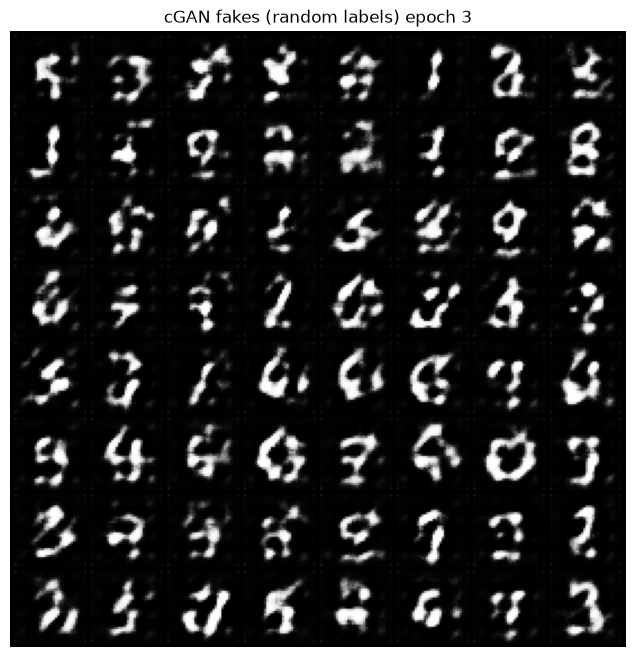

Conditional GAN training finished.


In [11]:
# =============================================================================
# TRAIN cGAN — same D-then-G turns, but labels ride along
# =============================================================================
#
# Real batch:  (real photo, its true digit)     D should say 1
# Fake batch:  G(z, SAME digit), that digit     D should say 0
# G's job:     make D say 1 for (fake, that digit)
#
# Using the real labels on fakes teaches G "when I ask for 3, draw a 3"
# not a random other class.
#
# Demo length: 3 epochs × 80 batches (same CPU shortcut as DCGAN).
# One picture at the last epoch only.
#

n_classes = 10
epochs = 3
max_batches = 80

netG_c = ConditionalGenerator().to(device)
netD_c = ConditionalDiscriminator().to(device)
netG_c.apply(weights_init)
netD_c.apply(weights_init)

criterion = nn.BCELoss()
optimizerD_c = optim.Adam(netD_c.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG_c = optim.Adam(netG_c.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise_c = torch.randn(64, latent_dim, device=device)
fixed_labels_c = torch.randint(0, n_classes, (64,), device=device)

G_losses_c, D_losses_c = [], []

print("Starting Conditional GAN Training...")
print(f"(demo: {epochs} epochs × {max_batches} batches)")
for epoch in range(epochs):
    for i, (real_imgs, labels) in enumerate(train_loader):
        if i >= max_batches:
            break
        bsz = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)

        netD_c.zero_grad()
        label_real = torch.full((bsz,), 1.0, device=device)
        errD_real = criterion(netD_c(real_imgs, labels), label_real)
        errD_real.backward()

        noise = torch.randn(bsz, latent_dim, device=device)
        fake_imgs = netG_c(noise, labels)
        label_fake = torch.full((bsz,), 0.0, device=device)
        errD_fake = criterion(netD_c(fake_imgs.detach(), labels), label_fake)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD_c.step()

        netG_c.zero_grad()
        label_real.fill_(1.0)
        errG = criterion(netD_c(fake_imgs, labels), label_real)
        errG.backward()
        optimizerG_c.step()

        G_losses_c.append(errG.item())
        D_losses_c.append(errD.item())

        if i % 40 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] Batch {i}/{max_batches}  "
                f"Loss D: {errD.item():.4f}, Loss G: {errG.item():.4f}"
            )

    if epoch + 1 == epochs:
        with torch.no_grad():
            fake = netG_c(fixed_noise_c, fixed_labels_c).detach().cpu()
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"cGAN fakes (random labels) epoch {epoch+1}")
        plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
        plt.show()

print("Conditional GAN training finished.")

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# Loss D / G: same wrestling as DCGAN. Alive messy numbers = good.
# Last grid: mixed digits (labels were random). Next cell asks G for 0,1,…,9
# on purpose so you can CHECK the slip actually controls the drawing.


In [ ]:
# =============================================================================
# PIX2PIX — cGAN where the "label" is another PICTURE
# =============================================================================
#
# DCGAN:  noise → photo
# cGAN:   noise + digit id → photo
# Pix2Pix: input photo → output photo   (edges→bag, day→night, sketch→color)
# 
# What is a U-Net?
# U-Net stands for "U-shaped Network" because of its symmetric, U-shaped architecture.
# It is an encoder-decoder neural network originally designed for biomedical image segmentation,
# but widely used for many image-to-image translation tasks.
# The "U" shape comes from its structure: a downsampling (encoder) path to capture context,
# followed by an upsampling (decoder) path to enable precise localization.
# Skip connections between corresponding encoder and decoder layers copy spatial information directly
# 
# Generator is a U-Net:
# across, helping preserve fine details in the output image.
#   go DOWN (compress) then UP (rebuild), and SKIP connections copy
#   fine details from down to up so edges don't get lost.
#
# Picture:
#   input ──down──down──down── bottleneck
#     │        │        │           │
#     └─skip───┴─skip───┴─skip──  up, up, up ──▶ output
#
# This cell is a SHAPE sketch (typical 256-style U-Net). We do not train it
# on a huge paired dataset here — too heavy for this lesson.
#

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=64):
        super().__init__()
        self.down1 = self._block(in_channels, features, use_bn=False)
        self.down2 = self._block(features, features * 2)
        self.down3 = self._block(features * 2, features * 4)
        self.down4 = self._block(features * 4, features * 8)
        self.down5 = self._block(features * 8, features * 8)
        self.down6 = self._block(features * 8, features * 8)
        self.down7 = self._block(features * 8, features * 8)
        self.bottleneck = self._block(features * 8, features * 8, use_dropout=True)

        # cat doubles channels → features*16 in on the first ups
        self.up1 = self._up_block(features * 16, features * 8)
        self.up2 = self._up_block(features * 16, features * 8)
        self.up3 = self._up_block(features * 16, features * 8)
        self.up4 = self._up_block(features * 16, features * 4)
        self.up5 = self._up_block(features * 8, features * 2)
        self.up6 = self._up_block(features * 4, features)
        self.up7 = self._up_block(features * 2, out_channels, use_activation=False)

    def _block(self, in_ch, out_ch, use_bn=True, use_dropout=False):
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        if use_dropout:
            layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def _up_block(self, in_ch, out_ch, use_activation=True):
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        ]
        layers.append(nn.ReLU(True) if use_activation else nn.Tanh())
        return nn.Sequential(*layers)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        b = self.bottleneck(d7)
        u1 = self.up1(torch.cat([b, d7], dim=1))
        u2 = self.up2(torch.cat([u1, d6], dim=1))
        u3 = self.up3(torch.cat([u2, d5], dim=1))
        u4 = self.up4(torch.cat([u3, d4], dim=1))
        u5 = self.up5(torch.cat([u4, d3], dim=1))
        u6 = self.up6(torch.cat([u5, d2], dim=1))
        u7 = self.up7(torch.cat([u6, d1], dim=1))
        return u7


# Sanity: 256×256 RGB in → 256×256 RGB out (if your GPU/RAM allows a dummy)
try:
    _g = UNetGenerator()
    _y = _g(torch.zeros(1, 3, 256, 256))
    print(f"U-Net dummy out: {tuple(_y.shape)}  (want 1,3,256,256)")
except Exception as e:
    print("U-Net dummy skipped:", type(e).__name__, e)


U-Net dummy skipped: ValueError Expected more than 1 value per channel when training, got input size torch.Size([1, 512, 1, 1])


In [13]:
# =============================================================================
# PATCHGAN — detective that grades TILES, not one score for the whole photo
# =============================================================================
#
# DCGAN D: one number for the entire 32×32 image.
# PatchGAN: a small GRID of scores. Each cell = "does THIS patch look real?"
#
# Why: pix2pix cares about sharp local texture (edges, bricks), not only
# "does the whole scene feel like a photo?"
#
# Input to D: concat(generated_or_real, condition_image) → 6 channels
# if both are RGB. Output: e.g. 30×30 map, trained with BCE on every cell.
#
# Loss people combine:  adversarial (fool PatchGAN)  +  L1(|fake - target|)
# L1 keeps colors/layout close to the paired ground truth.
#

class PatchGAN(nn.Module):
    def __init__(self, in_channels=6, features=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 4, features * 8, 4, 1, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 8, 1, 4, 1, 1, bias=False),
        )

    def forward(self, x, condition):
        x = torch.cat([x, condition], dim=1)
        return self.model(x)


try:
    _d = PatchGAN()
    _p = _d(torch.zeros(1, 3, 256, 256), torch.zeros(1, 3, 256, 256))
    print(f"PatchGAN dummy out: {tuple(_p.shape)}  (grid of real/fake scores)")
except Exception as e:
    print("PatchGAN dummy skipped:", type(e).__name__, e)

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# U-Net dummy out: (1, 3, 256, 256) — same size photo in/out.
# PatchGAN dummy out: (1, 1, H, W) — not a single scalar. Each H×W cell
# is one patch verdict.


PatchGAN dummy out: (1, 1, 30, 30)  (grid of real/fake scores)


--- cGAN class control ---


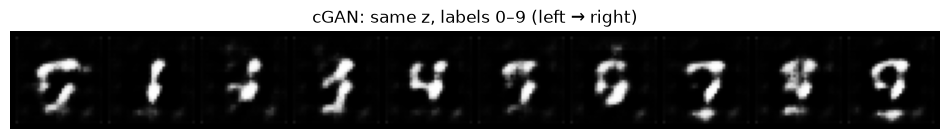

labels left→right: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
--- DCGAN interpolation ---


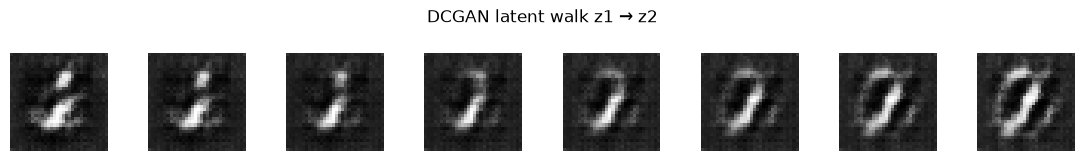

In [14]:
# =============================================================================
# MINI-PROJECT — did the request slip work? + morph between two fakes
# =============================================================================
#
# 1) Ask cGAN for digits 0..9 (same z, changing only the label).
#    If the slip works, the row should change identity, not just noise.
#    After a 3-epoch demo they may be blurry — look for *different* shapes.
#
# 2) Interpolate two DCGAN z-vectors: walk z1 → z2 and watch the digit melt.
#    Smooth melt = G learned a usable map. Sudden junk = still undertrained.
#

def show_cgan_digit_row(netG_c, device, latent_dim=100, n_classes=10):
    """One image per class: label 0,1,…,9 with the SAME noise."""
    netG_c.eval()
    z = torch.randn(1, latent_dim, device=device).repeat(n_classes, 1)
    labels = torch.arange(n_classes, device=device)
    with torch.no_grad():
        fake = netG_c(z, labels).cpu()
    plt.figure(figsize=(12, 2))
    plt.axis("off")
    plt.title("cGAN: same z, labels 0–9 (left → right)")
    plt.imshow(np.transpose(vutils.make_grid(fake, nrow=10, padding=2, normalize=True), (1, 2, 0)))
    plt.show()
    print("labels left→right:", list(range(n_classes)))


def interpolate_latent(netG, z1, z2, steps=8, device=device):
    """DCGAN only: netG(z) with no label."""
    netG.eval()
    imgs = []
    with torch.no_grad():
        for a in np.linspace(0, 1, steps):
            z = (1 - a) * z1 + a * z2
            imgs.append(netG(z.unsqueeze(0).to(device)).cpu().squeeze())
    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.4, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i], cmap="gray")
        ax.axis("off")
    plt.suptitle("DCGAN latent walk z1 → z2")
    plt.tight_layout()
    plt.show()


print("--- cGAN class control ---")
try:
    show_cgan_digit_row(netG_c, device, latent_dim)
except NameError:
    print("netG_c missing — run the cGAN train cell first.")

print("--- DCGAN interpolation ---")
try:
    z1 = torch.randn(latent_dim)
    z2 = torch.randn(latent_dim)
    interpolate_latent(netG, z1, z2)
except NameError:
    print("netG missing — run the DCGAN train cell first.")

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# cGAN row: ideally 0 then 1 then 2 … After a short CPU demo, maybe only
# "these 10 blobs are not identical." That's the seed of control.
#
# DCGAN walk: left image morphs into the right. Gray smear in the middle
# is common when training was short.
